# Final Project: Drug Use Analysis Among Youth by Age

**Course:** SEIS 631 – Data Preparation and Analysis  
**Professor:** Dr. John  
**Student:** Debisa Woyessa  

## Project Topic
Choose Your Own Hypothesis: EDA Check-in
Project Topic: Youth Drug Use by Age

## Overview
This notebook presents an exploratory data analysis (EDA) of drug use using the *drug-use-by-age* dataset. The goal is to identify trends, compare substances, and analyze relationships between use and frequency variables. The findings are used to provide meaningful interpretation and policy recommendations.

Best Dataset Choice
Dataset: FiveThirtyEight – drug-use-by-age.csv
Why this dataset is best
This dataset is the best choice for this project because it directly matches the topic, Youth Drug Use by
Age. It is simple, clean, and works well in VS Code/Jupyter Notebook. The dataset includes age groups
(including youth ages 12–17) and multiple substance-use variables such as alcohol, marijuana, cocaine,
and others.
It is also appropriate for:
Exploratory Data Analysis (EDA)
Data visualization (graphs and histograms)
Statistical testing (permutation and bootstrap)
Final Recommendation
I will use the FiveThirtyEight drug-use-by-age.csv dataset because it is manageable, directly related


Research Question
How does marijuana use differ across age groups, especially among youth (12–17), young adults (18–
35), and older adults (35+)?



Hypotheses
H₀: There is no difference in average marijuana use across age groups.
H₁: There is a difference in average marijuana use across age groups.


Age Groups
Youth: ages 12–17
Young Adults: ages 18–35
Older Adults: ages 35 and above.

1.Import Libraries
Question: What Python libraries do we need?

In [1]:
import pandas  as pd
import numpy as np
 

import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pyplot as plt

df = pd.read_csv('drug-use-by-age.csv')

2.Load Dataset
Question: How do we load the dataset?

In [2]:
for col in df.columns:
    if col != 'age':
        df[col] = pd.to_numeric(df[col], errors='coerce')

3.Check Variables
Question: What variables are included in the dataset?

In [3]:
df.head()
df.columns

Index(['age', 'n', 'alcohol_use', 'alcohol_frequency', 'marijuana_use',
       'marijuana_frequency', 'cocaine_use', 'cocaine_frequency', 'crack_use',
       'crack_frequency', 'heroin_use', 'heroin_frequency', 'hallucinogen_use',
       'hallucinogen_frequency', 'inhalant_use', 'inhalant_frequency',
       'pain_releiver_use', 'pain_releiver_frequency', 'oxycontin_use',
       'oxycontin_frequency', 'tranquilizer_use', 'tranquilizer_frequency',
       'stimulant_use', 'stimulant_frequency', 'meth_use', 'meth_frequency',
       'sedative_use', 'sedative_frequency'],
      dtype='object')

In [4]:
df.isnull().sum()

age                        0
n                          0
alcohol_use                0
alcohol_frequency          0
marijuana_use              0
marijuana_frequency        0
cocaine_use                0
cocaine_frequency          1
crack_use                  0
crack_frequency            3
heroin_use                 0
heroin_frequency           1
hallucinogen_use           0
hallucinogen_frequency     0
inhalant_use               0
inhalant_frequency         1
pain_releiver_use          0
pain_releiver_frequency    0
oxycontin_use              0
oxycontin_frequency        1
tranquilizer_use           0
tranquilizer_frequency     0
stimulant_use              0
stimulant_frequency        0
meth_use                   0
meth_frequency             2
sedative_use               0
sedative_frequency         0
dtype: int64

4.Clean Column Names
Question: How can we make column names easier to use?

In [5]:
df.columns = df.columns.str.replace("-", "_")
df.columns

Index(['age', 'n', 'alcohol_use', 'alcohol_frequency', 'marijuana_use',
       'marijuana_frequency', 'cocaine_use', 'cocaine_frequency', 'crack_use',
       'crack_frequency', 'heroin_use', 'heroin_frequency', 'hallucinogen_use',
       'hallucinogen_frequency', 'inhalant_use', 'inhalant_frequency',
       'pain_releiver_use', 'pain_releiver_frequency', 'oxycontin_use',
       'oxycontin_frequency', 'tranquilizer_use', 'tranquilizer_frequency',
       'stimulant_use', 'stimulant_frequency', 'meth_use', 'meth_frequency',
       'sedative_use', 'sedative_frequency'],
      dtype='object')

5.Clean Missing Values

In [6]:
df = df.replace("-", np.nan)

for col in df.columns:
    if col != "age":
        df[col] = pd.to_numeric(df[col], errors="coerce")

df.head()

,age,n,alcohol_use,alcohol_frequency,marijuana_use,marijuana_frequency,cocaine_use,cocaine_frequency,crack_use,crack_frequency,...,oxycontin_use,oxycontin_frequency,tranquilizer_use,tranquilizer_frequency,stimulant_use,stimulant_frequency,meth_use,meth_frequency,sedative_use,sedative_frequency
0,12,2798,3.9,3.0,1.1,4.0,0.1,5.0,0.0,NaN,...,0.1,24.5,0.2,52.0,0.2,2.0,0.0,NaN,0.2,13.0
1,13,2757,8.5,6.0,3.4,15.0,0.1,1.0,0.0,3.0,...,0.1,41.0,0.3,25.5,0.3,4.0,0.1,5.0,0.1,19.0
2,14,2792,18.1,5.0,8.7,24.0,0.1,5.5,0.0,NaN,...,0.4,4.5,0.9,5.0,0.8,12.0,0.1,24.0,0.2,16.5
3,15,2956,29.2,6.0,14.5,25.0,0.5,4.0,0.1,9.5,...,0.8,3.0,2.0,4.5,1.5,6.0,0.3,10.5,0.4,30.0
4,16,3058,40.1,10.0,22.5,30.0,1.0,7.0,0.0,1.0,...,1.1,4.0,2.4,11.0,1.8,9.5,0.3,36.0,0.2,3.0


6.Check Data Size
Question: How many rows and columns are in the dataset?

In [7]:

df.shape

(17, 28)

7.Create Age Groups

In [8]:

# Creating Age Groups for Drug Use Analysis

def assign_age_group(age):
    # handle missing values
    if pd.isna(age):
        return "Unknown"

    age = str(age).strip()

    try:
        # handle ranges like "22-23"
        if "-" in age:
            start = int(age.split("-")[0])
        else:
            start = int(age)

        if 12 <= start <= 17:
            return "Youth (12-17)"
        elif 18 <= start <= 34:
            return "Young Adults (18-34)"
        else:
            return "Older Adults (35+)"
    
    except:
        return "Unknown"
    

In [9]:

df["age_group"] = df["age"].apply(assign_age_group)
df[["age", "age_group"]].head()

,age,age_group
0,12,Youth (12-17)
1,13,Youth (12-17)
2,14,Youth (12-17)
3,15,Youth (12-17)
4,16,Youth (12-17)


8.Summary Statistics
Question: What are the summary statistics for marijuana use?

In [10]:
df["marijuana_use"].describe()

count    17.000000
mean     18.923529
std      11.959752
min       1.100000
25%       8.700000
50%      20.800000
75%      28.400000
max      34.000000
Name: marijuana_use, dtype: float64

9.Marijuana Use by Age
Question: How does marijuana use change by age?


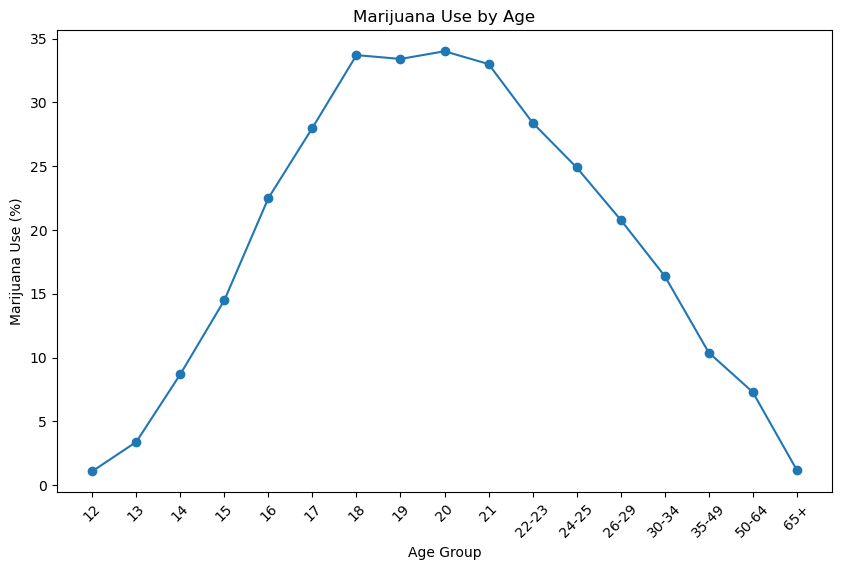

In [11]:

plt.figure(figsize=(10, 6))
plt.plot(df["age"], df["marijuana_use"], marker="o")
plt.xlabel("Age Group")
plt.ylabel("Marijuana Use (%)")
plt.title("Marijuana Use by Age")
plt.xticks(rotation=45)
plt.show()

10.Histogram of Marijuana Use
Question: What does the distribution of marijuana use look like?


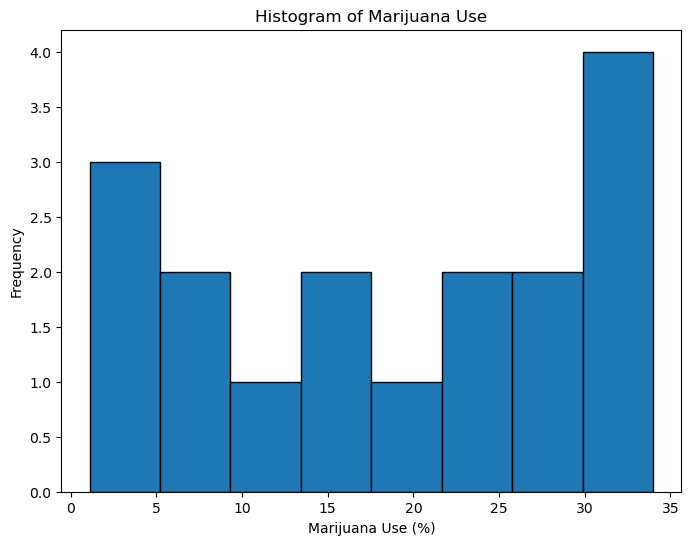

In [12]:

plt.figure(figsize=(8, 6))
plt.hist(df["marijuana_use"], bins=8, edgecolor="black")
plt.xlabel("Marijuana Use (%)")
plt.ylabel("Frequency")
plt.title("Histogram of Marijuana Use")
plt.show()

11.Alcohol Use by Age
Question: How does alcohol use change by age?

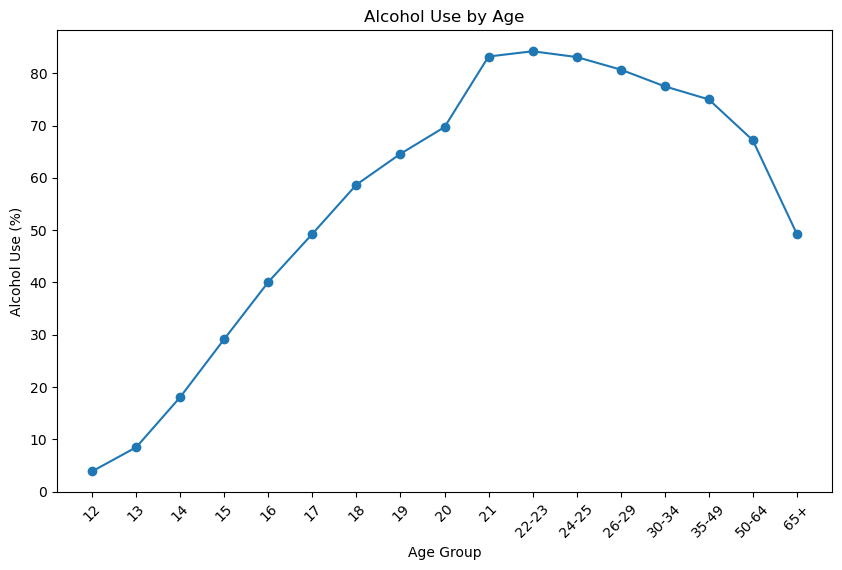

In [13]:

plt.figure(figsize=(10, 6))
plt.plot(df["age"], df["alcohol_use"], marker="o")
plt.xlabel("Age Group")
plt.ylabel("Alcohol Use (%)")
plt.title("Alcohol Use by Age")
plt.xticks(rotation=45)
plt.show()


12.Compare Alcohol and Marijuana
Question: How do alcohol and marijuana use compare?

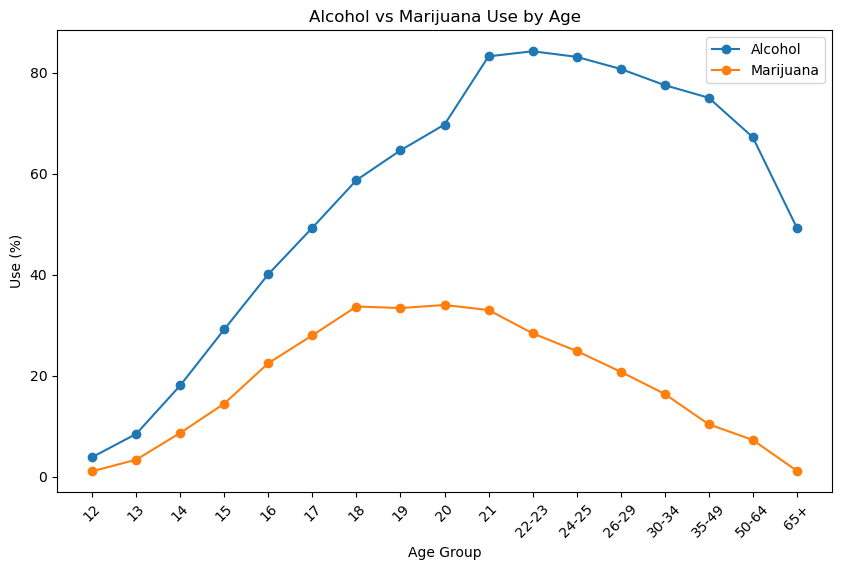

In [14]:

plt.figure(figsize=(10, 6))
plt.plot(df["age"], df["alcohol_use"], marker="o", label="Alcohol")
plt.plot(df["age"], df["marijuana_use"], marker="o", label="Marijuana")
plt.legend()
plt.xlabel("Age Group")
plt.ylabel("Use (%)")
plt.title("Alcohol vs Marijuana Use by Age")
plt.xticks(rotation=45)
plt.show()

3 Average Marijuana Use by Age Group
Question: What is the average marijuana use for each age group?


In [15]:

group_means = df.groupby("age_group")["marijuana_use"].mean()
group_means

age_group
Older Adults (35+)       8.850000
Unknown                  1.200000
Young Adults (18-34)    28.075000
Youth (12-17)           13.033333
Name: marijuana_use, dtype: float64

14.Bar Chart

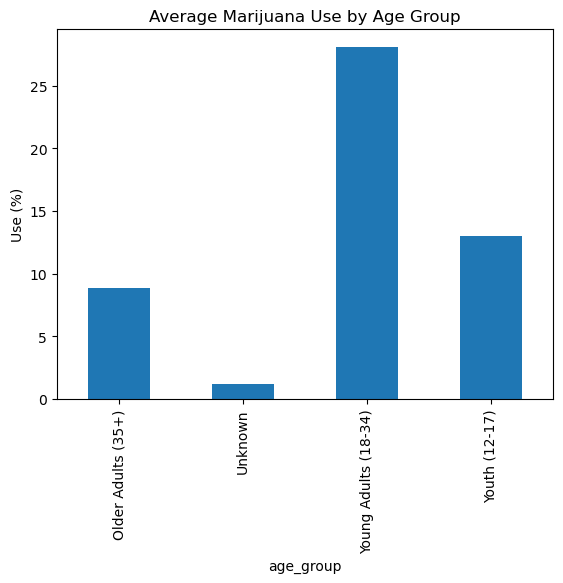

In [16]:
group_means.plot(kind="bar")
plt.title("Average Marijuana Use by Age Group")
plt.ylabel("Use (%)")
plt.show()

15.Highest Substance Use

In [17]:

use_columns = [col for col in df.columns if col.endswith("_use")]
average_use = df[use_columns].mean().sort_values(ascending=False)
average_use


alcohol_use          55.429412
marijuana_use        18.923529
pain_releiver_use     6.270588
hallucinogen_use      3.394118
tranquilizer_use      2.805882
cocaine_use           2.176471
stimulant_use         1.917647
inhalant_use          1.388235
oxycontin_use         0.935294
meth_use              0.382353
heroin_use            0.352941
crack_use             0.294118
sedative_use          0.282353
dtype: float64

16.Histogram of Alcohol Use

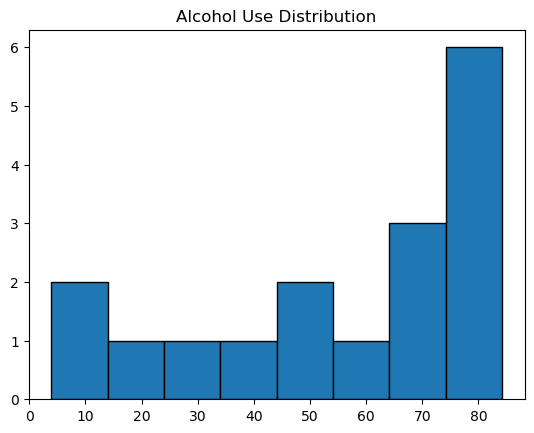

In [18]:

plt.hist(df["alcohol_use"], bins=8, edgecolor="black")
plt.title("Alcohol Use Distribution")
plt.show()


17.Conclusion

Answer:
The EDA shows that substance use varies by age group. Marijuana use increases from youth to young
adulthood and then changes among older adults. Alcohol use is generally higher than marijuana use.
These results suggest that age plays an important role in substance use behavior.

18. Limitation
Answer:
This dataset does not include geographic or time variables such as city, county, state, or year.
Therefore, it cannot be used for Twin Cities or location-based analysis.
